# 03 — H2: convective organization vs shear at fixed CAPE (A3)
P(MCS), MCS area, and MCS rainfall fraction across (CAPE×shear). Does shear push toward organized systems at given CAPE?

In [1]:
import sys; sys.path.insert(0, '.')
from _shc import *
con = connect()


### P(feature is an MCS)

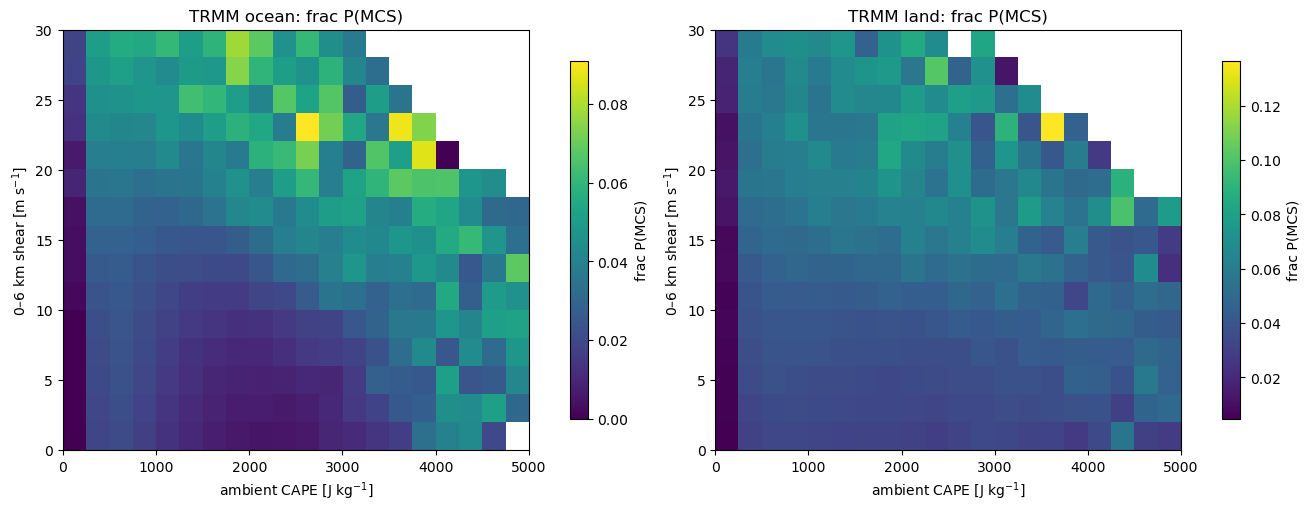

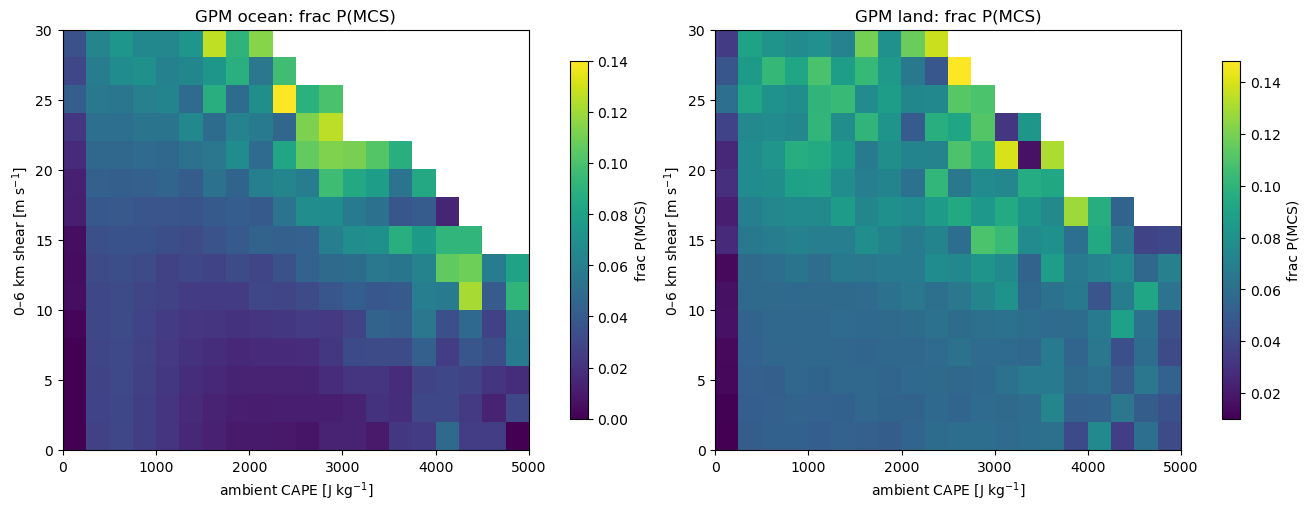

In [2]:
plot_composite(con,'is_mcs',mission='TRMM',label='P(MCS)',stat='frac',cmap='viridis')
plot_composite(con,'is_mcs',mission='GPM',label='P(MCS)',stat='frac',cmap='viridis')

### Feature area & convective area vs shear at fixed CAPE

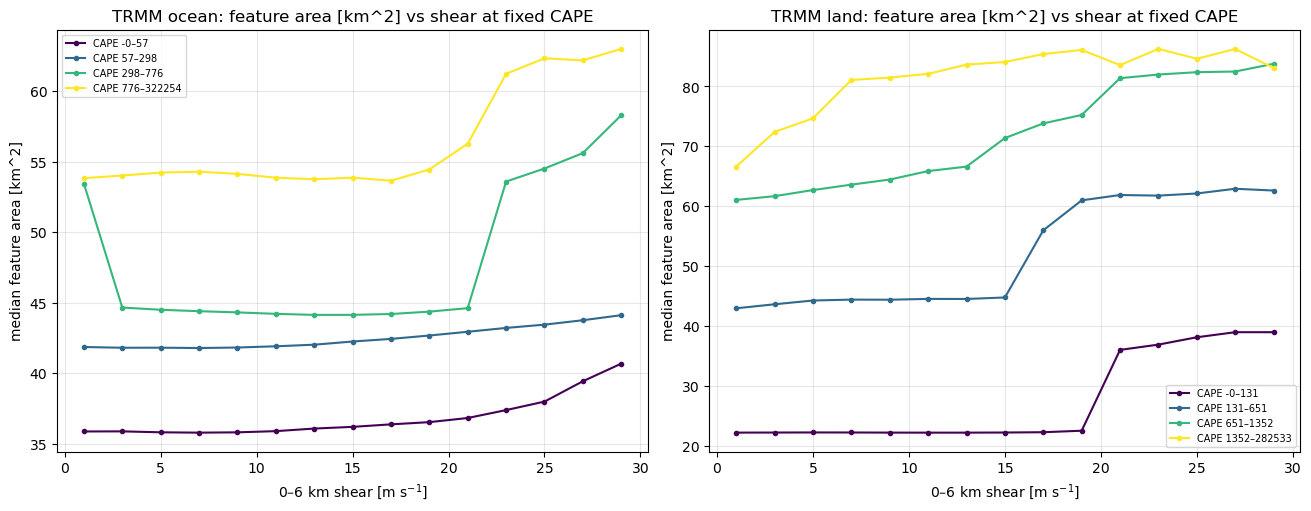

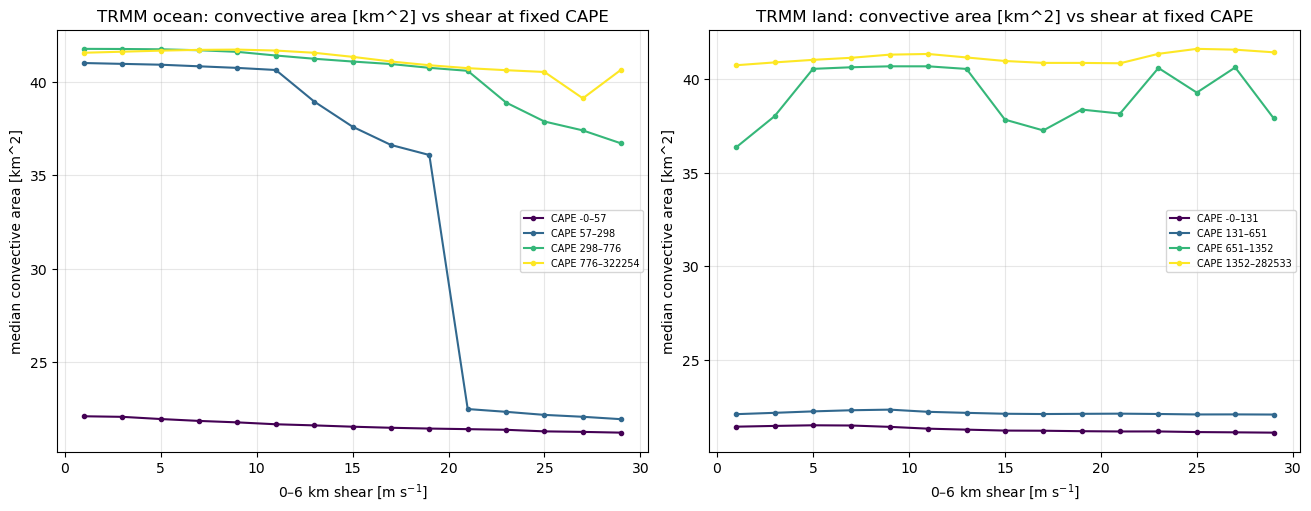

In [3]:
plot_fixed_cape(con,'area_km2',mission='TRMM',label='feature area [km^2]')
plot_fixed_cape(con,'conv_area_km2',mission='TRMM',label='convective area [km^2]')

### MCS rainfall fraction in (CAPE×shear) — share of rain from organized systems

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

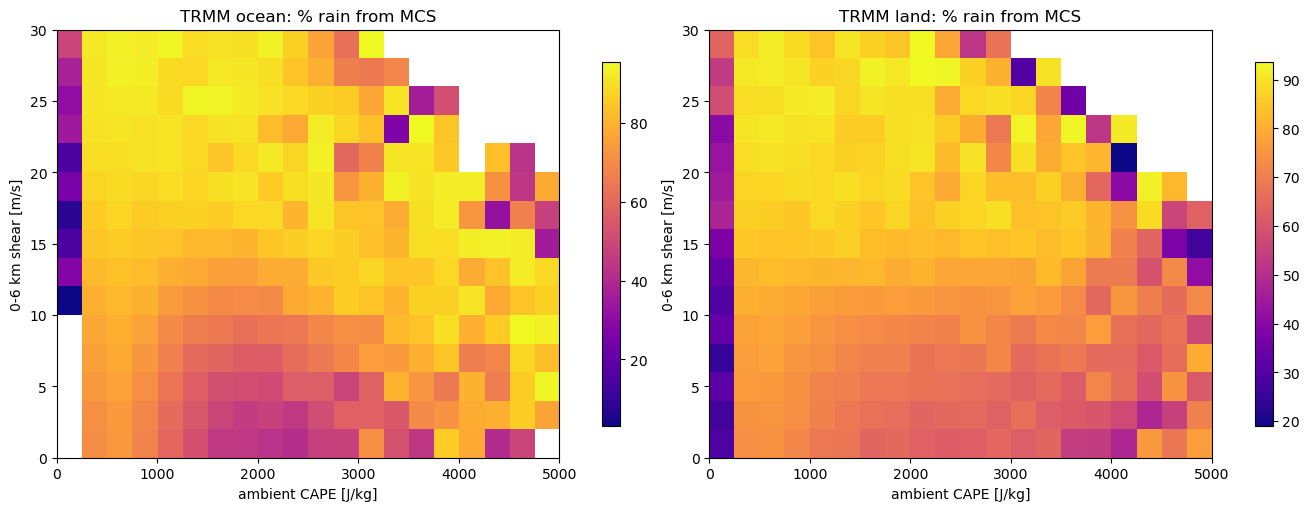

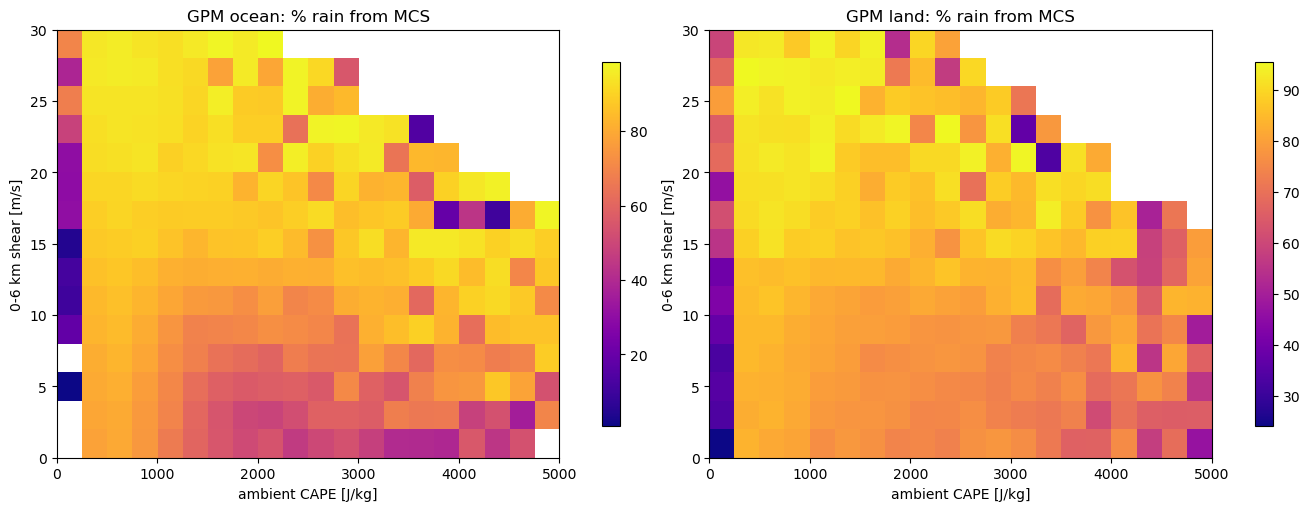

In [4]:
for m in ['TRMM','GPM']:
    fig,axes=plt.subplots(1,2,figsize=(13,5),constrained_layout=True)
    for ax,surf in zip(axes,['ocean','land']):
        d=q(con, f'''SELECT floor({AMBIENT_CAPE}/{CAPE_W})*{CAPE_W} cb, floor({SHEAR}/{SHEAR_W})*{SHEAR_W} sb,
             100.0*sum(volrain_total) FILTER(WHERE feature_class=\'MCS\')/sum(volrain_total) v, count(*) n
             FROM fe WHERE mission=? AND surf=? AND {AMBIENT_CAPE}<{CAPE_MAX} AND {SHEAR}<{SHEAR_MAX}
             GROUP BY 1,2 HAVING count(*)>={MIN_BIN_N}''', m, surf)
        import numpy as np; ncb,nsb=int(CAPE_MAX/CAPE_W),int(SHEAR_MAX/SHEAR_W); G=np.full((nsb,ncb),np.nan)
        G[(d.sb/SHEAR_W).astype(int).clip(0,nsb-1),(d.cb/CAPE_W).astype(int).clip(0,ncb-1)]=d.v
        im=ax.imshow(np.ma.masked_invalid(G),origin='lower',aspect='auto',extent=[0,CAPE_MAX,0,SHEAR_MAX],cmap='plasma')
        ax.set_xlabel('ambient CAPE [J/kg]'); ax.set_ylabel('0-6 km shear [m/s]'); ax.set_title(f'{m} {surf}: % rain from MCS')
        fig.colorbar(im,ax=ax,shrink=.85)
    plt.show()